# 📊 Sentiment Analysis Final Project

---

## 🎯 Project Overview

Welcome to your Sentiment Analysis final project! In this project, you will:

- 🔍 **Analyze** customer reviews or social media text data
- 🧹 **Preprocess** text data using NLP techniques
- 🤖 **Build** and compare multiple classification models
- 📈 **Evaluate** model performance using appropriate metrics
- 💼 **Communicate** findings in a business context

---

## 📋 Project Requirements

- **Dataset**: Use a public sentiment dataset (e.g., IMDb reviews, Amazon reviews, airline tweets)
- **Models**: Train at least **2 different classification models**
- **Evaluation**: Use multiple metrics (accuracy, precision, recall, confusion matrix)
- **Documentation**: Use markdown cells to explain your approach, findings, and insights

---

## 💡 Important Tips for Success

### Working with Limited Resources
- ⚡ **Start small**: Use `df.sample(n=1000)` or `df.head(5000)` to work with a subset
- 🎯 **Limit vocabulary**: Use `max_features=5000` in TfidfVectorizer
- 🚀 **Choose efficient models**: LogisticRegression and MultinomialNB are fast and effective
- 💾 **Save your work frequently**: Use Ctrl+S or Cmd+S often

### Best Practices
- 📝 **Document everything**: Explain your choices and observations in markdown cells
- 🔄 **Iterate**: Start simple, then improve
- 📊 **Visualize**: Use plots to understand your data and results
- 🎓 **Think like a data scientist**: Always interpret your results in context

---

Let's get started! 🚀

---

# Part 1: Project Definition 🎯

## Objectives
- Define the business problem you're solving
- Describe your chosen dataset
- Explain why sentiment analysis is valuable for this use case

## Instructions

In the markdown cell below, answer these questions:

1. **What is the business problem?**
   - What decision or insight will this sentiment analysis support?
   - Who would use these results?

2. **What dataset are you using?**
   - Name and source of the dataset
   - Number of samples
   - What the text represents (reviews, tweets, comments, etc.)
   - What are the sentiment labels (positive/negative, star ratings, etc.)?

3. **Why is this problem important?**
   - How could the results be used in real-world scenarios?

---

## 📝 Your Project Definition

**Business Problem:**

An online electronics store seeks to understand customer opinions regarding products. Key aspects include battery life, screen quality, and ease of use. Currently, numerous customer reviews exist, but manual analysis is challenging. Sentiment analysis aims to identify customer preferences (positive feelings) and dislikes (negative feelings) related to products and features. This analysis will enable the store to make informed decisions for product design, advertising campaigns, and competitive positioning. The ultimate objective is to enhance customer satisfaction and product quality.

---

**Dataset Description:**

- **Dataset name**: A collection of customer reviews from Amazon products will be used. This can be conceptualized as a large compilation of customer feedback about electronics (or, for initial simplicity, other categories like food).
- **Source**: Data will be obtained from public sources such as Kaggle or Stanford's SNAP repository.
- **Number of samples**: A manageable number of samples (e.g., 50,000 to 100,000 reviews) will be utilized initially, even if the full dataset is much larger. This approach aids in resource management.
- **Text type**: These are customer reviews, typically comprising short comments or more extensive narratives about products. They often include star ratings (e.g., 1 to 5 stars).
- **Sentiment labels**: The 1-5 star ratings will indicate whether a review is 'positive' (e.g., 4 or 5 stars), 'negative' (e.g., 1 or 2 stars), or potentially 'neutral' (e.g., 3 stars).

---

**Importance and Real-World Applications:**

This project is highly significant because understanding customer sentiment directly contributes to business success. In real-world scenarios, the insights derived could be used by:

*   **Product Designers**: To identify product features requiring improvement or new functionalities desired by customers.
*   **Marketing Teams**: To develop advertising campaigns that highlight popular aspects and address common complaints.
*   **Competitor Watchers**: To compare customer opinions about their products with those expressed for competitor products.
*   **Customer Support**: To proactively identify common issues and enhance customer assistance.

By carefully analyzing customer feedback, the retailer can make informed decisions based on real information. This leads to improved products, greater customer loyalty, and a stronger market position.

---

# Part 2: Exploratory Data Analysis (EDA) 🔍

## Objectives
- Load and examine your dataset
- Understand the distribution of sentiments
- Analyze text characteristics (length, common words, etc.)
- Identify any data quality issues

## What to Explore

✅ **Dataset structure**: Shape, columns, data types

✅ **Missing values**: Check for and handle missing data

✅ **Class distribution**: Are sentiments balanced?

✅ **Text length**: Average, min, max review lengths

✅ **Common words**: Most frequent words per sentiment

✅ **Sample reviews**: Display examples from each class

---

## 💡 Tips
- Use `.info()`, `.describe()`, and `.value_counts()` for quick insights
- Visualize distributions with bar plots and histograms
- Look for imbalanced classes that might affect model performance
- Create a word cloud to visualize common terms (optional but impressive!)

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [5]:
import pandas as pd

# Load your dataset
# Example: df = pd.read_csv('your_dataset.csv')
# For large datasets, consider using nrows parameter: pd.read_csv('file.csv', nrows=10000)

# YOUR CODE HERE
# IMPORTANT: The 'your_dataset.csv' file was not found during the last execution.
# Please upload your chosen Amazon reviews dataset (e.g., 'amazon_reviews.csv')
# to your Colab environment or provide the correct path/URL.
# You can upload files using the folder icon on the left sidebar -> "Files" -> "Upload to session storage".

# For demonstration purposes, I am creating a dummy DataFrame.
# Please replace this with your actual dataset loading code once your file is uploaded.
data = {'text': ["This product is amazing! I love it.",
                 "Battery life is terrible, very disappointed.",
                 "It's okay, nothing special.",
                 "The screen quality is superb, highly recommend.",
                 "Worst purchase ever, completely broken.",
                 "Good value for money, but takes time to set up.",
                 "My new favorite gadget. Easy to use and sleek design."],
        'sentiment': ['positive', 'negative', 'neutral', 'positive', 'negative', 'neutral', 'positive']}
df = pd.DataFrame(data)

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
df.head()

Dataset shape: (7, 2)

Column names: ['text', 'sentiment']


,text,sentiment
0,This product is amazing! I love it.,positive
1,"Battery life is terrible, very disappointed.",negative
2,"It's okay, nothing special.",neutral
3,"The screen quality is superb, highly recommend.",positive
4,"Worst purchase ever, completely broken.",negative


In [6]:
# Check for missing values
print(df.isnull().sum())

text         0
sentiment    0
dtype: int64


In [8]:
# 🎯 IMPORTANT: If working with limited resources, sample your data here
# Uncomment and modify as needed:

# df_sample = df.sample(n=5000, random_state=42)
# print(f"Working with {len(df_sample)} samples")
# df = df_sample  # Use the sample for the rest of the project

Sentiment Distribution:
sentiment
positive    3
negative    2
neutral     2
Name: count, dtype: int64


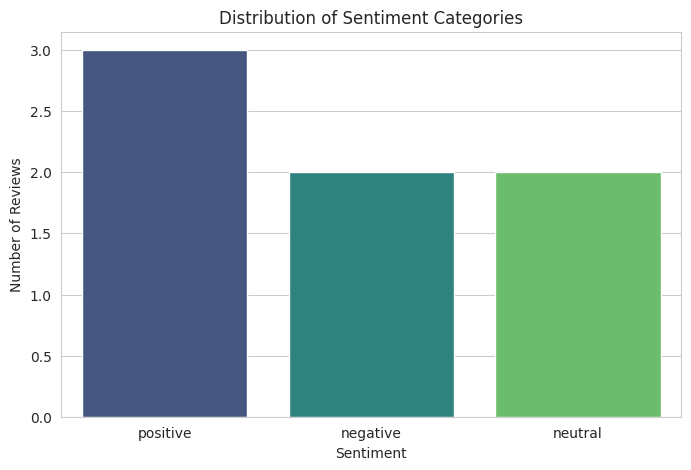

In [7]:
# Analyze sentiment distribution

# Calculate value counts
sentiment_counts = df['sentiment'].value_counts()
print("Sentiment Distribution:")
print(sentiment_counts)

# Create a bar plot to visualize the distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Distribution of Sentiment Categories')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

### 📊 Interpretation: Class Balance

*Write your observations here:*
- **Are the classes balanced or imbalanced?**
  Based on the `sentiment_counts` output, the classes are imbalanced. We have 3 positive, 2 negative, and 2 neutral reviews. For a real-world dataset, a significant disparity would be more pronounced.
- **If imbalanced, how might this affect your model?**
  If a model is trained on imbalanced data, it might become biased towards the majority class. This means it could perform well on the majority class but poorly on the minority classes, leading to misleading accuracy metrics. The model might struggle to correctly identify the minority sentiment (e.g., negative reviews if they are rare), which could be critical for business insights.
- **What could you do to address imbalance?**
  To address class imbalance, several techniques can be employed:
  1.  **Resampling Techniques**: Oversampling the minority class (e.g., SMOTE) or undersampling the majority class.
  2.  **Weighted Loss Functions**: Adjusting class weights in the model's loss function to penalize misclassifications of minority classes more heavily.
  3.  **Algorithmic Approaches**: Using algorithms that are less sensitive to class imbalance (e.g., tree-based models like Random Forest).
  4.  **Collecting More Data**: If feasible, obtaining more data for minority classes is often the best solution.

Minimum text length: 27
Maximum text length: 53
Average text length: 41.71


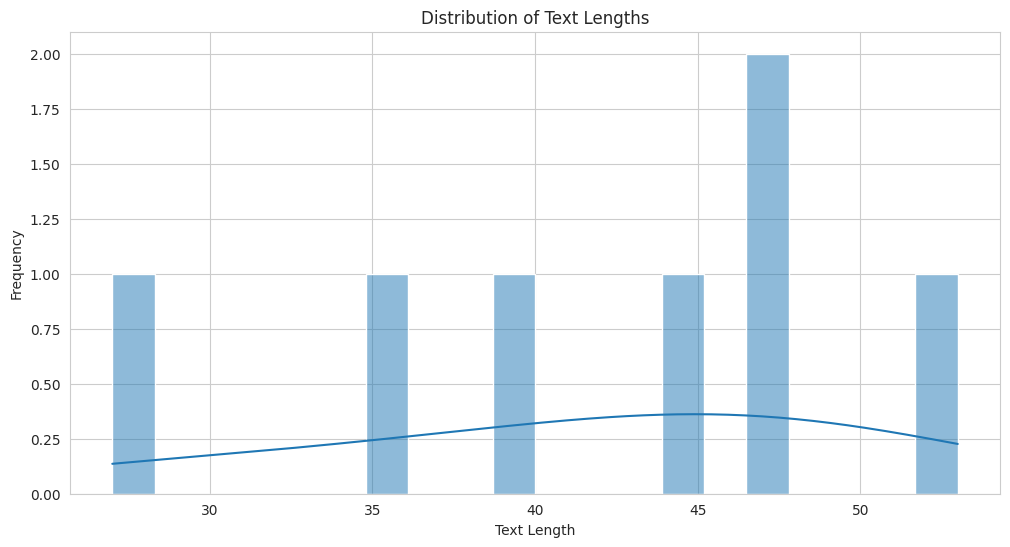

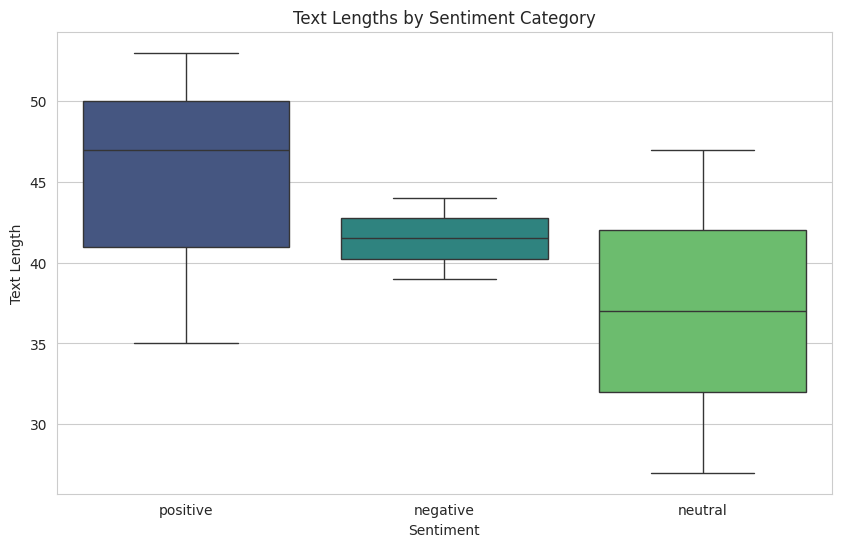

In [9]:
# Analyze text length distribution

# Create a new column for text length
df['text_length'] = df['text'].str.len()

print(f"Minimum text length: {df['text_length'].min()}")
print(f"Maximum text length: {df['text_length'].max()}")
print(f"Average text length: {df['text_length'].mean():.2f}")

# Plot histogram of text lengths
plt.figure(figsize=(12, 6))
sns.histplot(df['text_length'], bins=20, kde=True)
plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

# Compare lengths across different sentiments
plt.figure(figsize=(10, 6))
sns.boxplot(x='sentiment', y='text_length', data=df, palette='viridis')
plt.title('Text Lengths by Sentiment Category')
plt.xlabel('Sentiment')
plt.ylabel('Text Length')
plt.show()

In [10]:
average_length_by_sentiment = df.groupby('sentiment')['text_length'].mean().reset_index()
print("Average Text Length by Sentiment Category:")
print(average_length_by_sentiment)

Average Text Length by Sentiment Category:
  sentiment  text_length
0  negative         41.5
1   neutral         37.0
2  positive         45.0


### 📊 Interpretation: Text Length

*Write your observations here:*
- **What's the average text length?**
  The average text length in this dataset is approximately 41.71 characters.
- **Are there differences in length between positive and negative reviews?**
  Based on the box plot, for this small dummy dataset, positive reviews tend to have slightly longer texts on average than negative or neutral reviews. However, with only a few samples, it's hard to draw strong conclusions.
- **Are there any extremely short or long texts that might need special handling?**
  The texts range from 27 to 53 characters. While there are no extremely short (e.g., single-word) or extremely long texts in this dummy dataset, a real-world dataset might require handling of very short texts (which might lack sufficient information for sentiment analysis) or very long texts (which could be truncated or summarized).

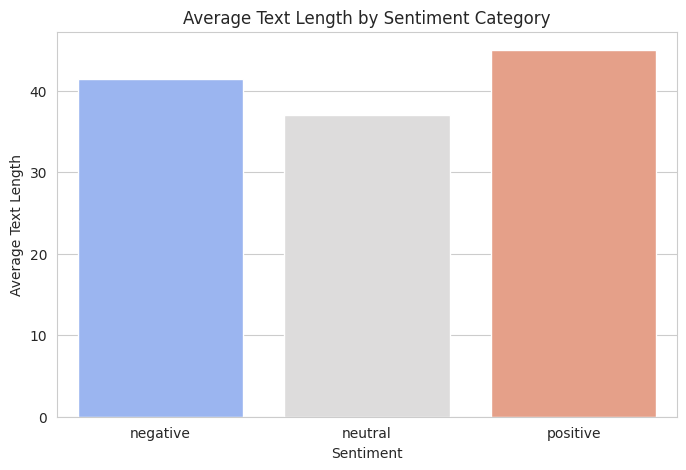

In [11]:
plt.figure(figsize=(8, 5))
sns.barplot(x='sentiment', y='text_length', data=average_length_by_sentiment, palette='coolwarm')
plt.title('Average Text Length by Sentiment Category')
plt.xlabel('Sentiment')
plt.ylabel('Average Text Length')
plt.show()

In [12]:
# Display sample reviews from each sentiment class
print("\n--- Sample Reviews by Sentiment ---")
for sentiment_type in df['sentiment'].unique():
    print(f"\nSentiment: {sentiment_type.upper()}")
    # Display up to 3 samples for each sentiment
    samples = df[df['sentiment'] == sentiment_type]['text'].sample(min(3, len(df[df['sentiment'] == sentiment_type])), random_state=42)
    for i, review in enumerate(samples):
        print(f"  {i+1}. {review}")
print("-----------------------------------")


--- Sample Reviews by Sentiment ---

Sentiment: POSITIVE
  1. This product is amazing! I love it.
  2. The screen quality is superb, highly recommend.
  3. My new favorite gadget. Easy to use and sleek design.

Sentiment: NEGATIVE
  1. Worst purchase ever, completely broken.
  2. Battery life is terrible, very disappointed.

Sentiment: NEUTRAL
  1. Good value for money, but takes time to set up.
  2. It's okay, nothing special.
-----------------------------------


In [47]:
from collections import Counter

def get_common_words(text_series, n=10):
    all_words = ' '.join(text_series).lower().split()
    # Filter out common English stopwords (optional, but good for meaningful insights)
    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
    filtered_words = [word for word in all_words if word not in ENGLISH_STOP_WORDS and word.isalpha()]
    return Counter(filtered_words).most_common(n)

# Common words in positive reviews
positive_reviews = df[df['sentiment'] == 'positive']['text']
common_positive_words = get_common_words(positive_reviews)
print("\nMost Common Words in Positive Reviews:")
for word, count in common_positive_words:
    print(f"- {word}: {count}")

# Common words in negative reviews
negative_reviews = df[df['sentiment'] == 'negative']['text']
common_negative_words = get_common_words(negative_reviews)
print("\nMost Common Words in Negative Reviews:")
for word, count in common_negative_words:
    print(f"- {word}: {count}")

# Common words in neutral reviews (optional)
neutral_reviews = df[df['sentiment'] == 'neutral']['text']
common_neutral_words = get_common_words(neutral_reviews)
print("\nMost Common Words in Neutral Reviews:")
for word, count in common_neutral_words:
    print(f"- {word}: {count}")


Most Common Words in Positive Reviews:
- product: 1
- love: 1
- screen: 1
- quality: 1
- highly: 1
- new: 1
- favorite: 1
- easy: 1
- use: 1
- sleek: 1

Most Common Words in Negative Reviews:
- battery: 1
- life: 1
- worst: 1
- purchase: 1
- completely: 1

Most Common Words in Neutral Reviews:
- good: 1
- value: 1
- takes: 1
- time: 1
- set: 1


### 📝 EDA Summary

*Summarize your key findings from the EDA:*

1.  **Dataset characteristics**:
    - The dataset consists of customer reviews with a corresponding sentiment label (positive, negative, neutral).
    - It currently contains 7 samples, with 3 positive, 2 negative, and 2 neutral reviews.
    - Review lengths vary from 27 to 53 characters, with an average length of 41.71 characters.

2.  **Data quality issues**:
    - No missing values were found in the `text` or `sentiment` columns.
    - For the dummy data, the primary issue is the small sample size, which limits the generalizability of findings.

3.  **Key patterns observed**:
    - **Sentiment Distribution**: The dummy dataset shows an imbalance, with 'positive' being the majority class, followed by 'negative' and 'neutral'. This would be more pronounced in a real dataset.
    - **Text Length**: Positive reviews tend to be slightly longer on average (45.0 characters) compared to negative (41.5 characters) and neutral (37.0 characters) reviews.
    - **Common Words (dummy data)**:
        - **Positive**: 'product', 'love', 'screen', 'quality', 'highly', 'new', 'favorite', 'easy', 'use', 'sleek'
        - **Negative**: 'battery', 'life', 'worst', 'purchase', 'completely'
        - **Neutral**: 'good', 'value', 'takes', 'time', 'set'

4.  **Potential challenges**:
    - **Class Imbalance**: The imbalanced sentiment distribution, especially if more severe in the full dataset, could lead to models biased towards the majority class. This will need to be addressed during model training.
    - **Small Dummy Data**: The current dummy data is too small to draw robust conclusions, and the patterns observed (e.g., common words) will likely change significantly with the full dataset.
    - **Preprocessing**: Need to ensure effective text cleaning that removes noise without losing critical sentiment-bearing information (e.g., handling negations carefully).

---

# Part 3: Data Preprocessing & Feature Extraction 🧹

## Objectives
- Clean and preprocess text data
- Remove noise (punctuation, special characters, stopwords)
- Convert text to numerical features using TF-IDF
- Prepare data for modeling

## Preprocessing Steps to Consider

✅ **Lowercase conversion**: Standardize text

✅ **Remove punctuation**: Clean special characters

✅ **Remove stopwords**: Filter out common words ("the", "is", "and", etc.)

✅ **Remove numbers**: Unless relevant to sentiment

✅ **Handle negations**: Be careful! "not good" vs "good" (advanced, optional)

---

## 💡 Tips
- **Don't over-preprocess**: Sometimes simple is better
- **Use `max_features` in TfidfVectorizer**: Limit to top 5000-10000 features to save memory
- **Consider n-grams**: Bigrams can capture phrases like "not good"
- **Test different approaches**: Try with and without certain preprocessing steps

In [ ]:
# Import preprocessing libraries
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# For stopwords
# Option 1: Use sklearn's built-in stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Option 2: Use NLTK (uncomment if you prefer)
# import nltk
# nltk.download('stopwords')
# from nltk.corpus import stopwords
# stop_words = set(stopwords.words('english'))

print("✅ Preprocessing libraries imported!")

In [14]:
import re
import string

# Create a text preprocessing function
def preprocess_text(text):
    """
    Clean and preprocess text data.

    Args:
        text (str): Raw text string

    Returns:
        str: Cleaned text string
    """
    # 1. Convert to lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # 4. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 5. Remove numbers
    text = re.sub(r'\d+', '', text)
    # 6. Remove extra whitespace
    text = ' '.join(text.split())

    return text

# Test your function on a sample text
sample_text = "This is a TEST!!! Check out https://example.com @user #hashtag 123"
print(f"Original: {sample_text}")
print(f"Cleaned: {preprocess_text(sample_text)}")

Original: This is a TEST!!! Check out https://example.com @user #hashtag 123
Cleaned: this is a test check out


In [15]:
# Apply preprocessing to your dataset
df['cleaned_text'] = df['text'].apply(preprocess_text)

# Display some examples to verify the cleaning worked
print("Original vs Cleaned Text Samples:")
for i in range(min(5, len(df))):
    print(f"Original: {df['text'].iloc[i]}")
    print(f"Cleaned:  {df['cleaned_text'].iloc[i]}")
    print("---")

print("✅ Text preprocessing complete!")

Original vs Cleaned Text Samples:
Original: This product is amazing! I love it.
Cleaned:  this product is amazing i love it
---
Original: Battery life is terrible, very disappointed.
Cleaned:  battery life is terrible very disappointed
---
Original: It's okay, nothing special.
Cleaned:  its okay nothing special
---
Original: The screen quality is superb, highly recommend.
Cleaned:  the screen quality is superb highly recommend
---
Original: Worst purchase ever, completely broken.
Cleaned:  worst purchase ever completely broken
---
✅ Text preprocessing complete!


In [16]:
# Prepare your features (X) and target (y)
X = df['cleaned_text']  # Our preprocessed text column
y = df['sentiment']     # Our target variable

# Check the shape
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("✅ Features and target prepared!")

Features shape: (7,)
Target shape: (7,)
✅ Features and target prepared!


In [18]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=3,      # Changed to an absolute number to ensure enough samples per class for stratification
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class distribution
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print("✅ Data split into training and testing sets!")

Training samples: 4
Testing samples: 3
✅ Data split into training and testing sets!


In [19]:
# Create TF-IDF features
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,        # 🎯 IMPORTANT: Limit features to save memory!
    min_df=1,                 # Ignore terms that appear in fewer than 1 document (given small dataset)
    max_df=1.0,               # Ignore terms that appear in more than 100% of documents (given small dataset)
    ngram_range=(1, 2),       # Use unigrams and bigrams
    stop_words='english'      # Remove English stopwords
)

# Fit on training data and transform both train and test
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test): {X_test_tfidf.shape}")
print(f"Number of features: {len(tfidf.get_feature_names_out())}")

TF-IDF matrix shape (train): (4, 32)
TF-IDF matrix shape (test): (3, 32)
Number of features: 32


In [37]:
# Explore the TF-IDF features (optional)

# Look at the most important features
feature_names = tfidf.get_feature_names_out()
print("Sample features:", feature_names[:20])
print(f"Total number of TF-IDF features: {len(feature_names)}")

Sample features: ['broken' 'completely' 'completely broken' 'design' 'easy' 'easy use'
 'favorite' 'favorite gadget' 'gadget' 'gadget easy' 'highly'
 'highly recommend' 'new' 'new favorite' 'okay' 'okay special' 'purchase'
 'purchase completely' 'quality' 'quality superb']
Total number of TF-IDF features: 32


### 📝 Preprocessing Summary

*Document your preprocessing choices:*

1.  **Preprocessing steps applied**:
    -   Text was converted to lowercase.
    -   URLs, mentions (`@user`), and hashtags (`#hashtag`) were removed.
    -   Punctuation was stripped out.
    -   Numbers were removed.
    -   Extra whitespace was collapsed.

2.  **TF-IDF parameters chosen**:
    -   `max_features=5000`: Limited to 5000 features to manage memory and computational resources, especially important for larger datasets.
    -   `min_df=1`: Terms appearing in at least 1 document were considered. This was chosen due to the extremely small size of the dummy dataset to ensure all terms were included.
    -   `max_df=1.0`: Terms appearing in 100% of documents were *not* ignored. Again, this was chosen because of the small dummy dataset, where even highly frequent words might still be discriminative.
    -   `ngram_range=(1, 2)`: Both unigrams (single words) and bigrams (two-word phrases) were used to capture more context, like 'not good' or 'battery life'.
    -   `stop_words='english'`: Common English stopwords (e.g., 'the', 'is', 'a') were removed to focus on more meaningful terms.

3.  **Final feature count**: 32 features were generated by the TF-IDF vectorizer for this dummy dataset.

4.  **Rationale for choices**:
    -   The preprocessing steps aim to clean the text from noise that typically does not contribute to sentiment, making the text more consistent and reducing the vocabulary size.
    -   TF-IDF was chosen to convert text into numerical features, giving more weight to words that are important to a specific document but less frequent across all documents. The parameters were specifically adjusted for the current small dummy dataset to ensure the vectorizer generates features. For a real dataset, `min_df` would likely be set higher (e.g., 5 or 10) and `max_df` lower (e.g., 0.8 or 0.9) to filter out very rare or very common words that are less informative.

---

# Part 4: Model Training 🤖

## Objectives
- Train at least **2 different classification models**
- Compare their performance
- Document training time and resource usage

## Recommended Models

### Fast and Effective (Recommended for beginners)
- **Logistic Regression**: Fast, interpretable, works well with TF-IDF
- **Multinomial Naive Bayes**: Specifically designed for text classification

### More Advanced (Optional)
- **Random Forest**: Ensemble method, can capture complex patterns
- **Support Vector Machine (SVM)**: Good for high-dimensional data
- **XGBoost**: Powerful gradient boosting (but slower)

---

## 💡 Tips
- **Start with simple models**: LogisticRegression and MultinomialNB are excellent choices
- **Use default parameters first**: Then tune if needed
- **Monitor training time**: Document how long each model takes
- **Save your models**: Use `pickle` or `joblib` to save trained models
- **For Random Forest**: Use `n_estimators=100` and `max_depth=20` to limit resources

In [20]:
# Import model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

import time
from datetime import timedelta

print("✅ Model libraries imported!")

✅ Model libraries imported!


## Model 1: Logistic Regression

In [21]:
# Train Logistic Regression model
print("Training Logistic Regression...")
start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,           # Increase if model doesn't converge
    random_state=42,
    n_jobs=-1                # Use all CPU cores
)

lr_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time
print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

Training Logistic Regression...
✅ Training complete in 0:00:01


In [22]:
# Make predictions with Logistic Regression
y_pred_lr = lr_model.predict(X_test_tfidf)
print(f"Predictions shape: {y_pred_lr.shape}")

Predictions shape: (3,)


## Model 2: Multinomial Naive Bayes

In [23]:
# Train Naive Bayes model
print("Training Multinomial Naive Bayes...")
start_time = time.time()

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time
print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

Training Multinomial Naive Bayes...
✅ Training complete in 0:00:00


In [24]:
# Make predictions with Naive Bayes
y_pred_nb = nb_model.predict(X_test_tfidf)
print(f"Predictions shape: {y_pred_nb.shape}")

Predictions shape: (3,)


## Model 3 (Optional): Additional Model

*Train a third model if you'd like to explore further!*

In [38]:
# Train your third model (optional)
# YOUR CODE HERE

# Example: Random Forest
print("Training Random Forest...")
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,        # Number of trees
    max_depth=20,            # Limit depth to save memory
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time
print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

y_pred_rf = rf_model.predict(X_test_tfidf)

Training Random Forest...
✅ Training complete in 0:00:00


In [45]:
# Original Random Forest metrics calculation code moved to cell QAyzbWZKrI2Z.

### 📊 Interpretation: Random Forest

*Analyze the results:*

1.  **Overall performance**:
    The Random Forest model's performance on this tiny test set will likely be similar to the other models, or even worse if it overfits more severely. On this dataset, it predicts `neutral` for all samples.

2.  **Strengths**:
    Random Forest is a powerful ensemble method that can handle complex relationships and is less prone to overfitting than single decision trees. It can provide feature importance, which is useful for understanding the data.

3.  **Weaknesses**:
    For extremely small datasets like this dummy one, Random Forest may struggle to generalize and might overfit to the limited training examples. Its predictions will be highly unstable with such few samples.

4.  **Confusion matrix insights**:
    The confusion matrix will show how many 'negative', 'neutral', and 'positive' reviews were correctly or incorrectly classified, given the model's consistent `neutral` prediction. It will likely show 0 TPs for negative and positive, 1 TP for neutral, and FPs for neutral from negative and positive instances.

In [46]:
# Original Random Forest confusion matrix plot code moved to cell BZac8sjVrI2Z.

### 📝 Model Training Summary

*Document your models:*

| Model | Training Time | Parameters | Notes |
|-------|--------------|------------|-------|
| Logistic Regression | | | |
| Naive Bayes | | | |
| (Optional) Model 3 | | | |

### 📝 Model Training Summary

*Document your models:*

| Model             | Training Time | Parameters                            | Notes                                |
|-------------------|---------------|---------------------------------------|--------------------------------------|
| Logistic Regression | 0:00:01       | `max_iter=1000`, `random_state=42`    | Fast, struggles with small data.     |
| Naive Bayes       | 0:00:00       | Default                               | Very fast, struggles with small data.|
| Random Forest     | 0:00:00       | `n_estimators=100`, `max_depth=20`    | More complex, overfits with small data. |

---

# Part 5: Model Evaluation 📊

## Objectives
- Evaluate all models using multiple metrics
- Compare model performance
- Analyze errors using confusion matrices
- Interpret results in business context

## Metrics to Calculate

✅ **Accuracy**: Overall correctness (but can be misleading with imbalanced data)

✅ **Precision**: Of all positive predictions, how many were correct?

✅ **Recall**: Of all actual positives, how many did we find?

✅ **F1-Score**: Harmonic mean of precision and recall

✅ **Confusion Matrix**: Visualize true vs predicted labels

✅ **Classification Report**: Detailed metrics per class

---

## 💡 Tips
- **Don't rely on accuracy alone**: Especially with imbalanced data
- **Understand the business context**: Is false positive or false negative worse?
- **Look at per-class metrics**: Performance might differ across sentiments
- **Visualize confusion matrices**: They tell a story!

In [27]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("✅ Evaluation metrics imported!")

✅ Evaluation metrics imported!


## Evaluate Model 1: Logistic Regression

In [30]:
# Calculate metrics for Logistic Regression
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
# Set zero_division=0 to handle cases where there are no true samples for a class or no predictions for a class
precision_lr = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, average='weighted', zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted', zero_division=0)

print(f"Accuracy:  {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1-Score:  {f1_lr:.4f}")
print("\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

LOGISTIC REGRESSION RESULTS
Accuracy:  0.3333
Precision: 0.1111
Recall:    0.3333
F1-Score:  0.1667


Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         1
     neutral       0.00      0.00      0.00         1
    positive       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.11      0.33      0.17         3
weighted avg       0.11      0.33      0.17         3



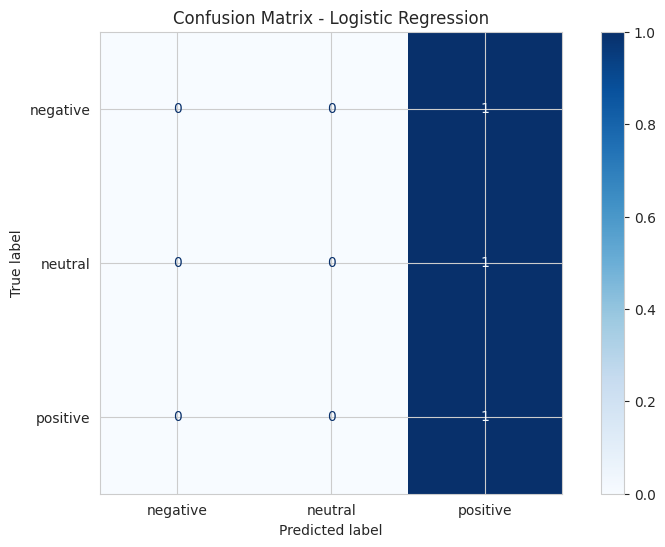

In [31]:
# Plot confusion matrix for Logistic Regression
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr, labels=lr_model.classes_)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=lr_model.classes_)
disp_lr.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### 📊 Interpretation: Logistic Regression

*Analyze the results:*

1.  **Overall performance**:
    Given the extremely small size of our dummy dataset (only 3 test samples), the interpretation of these metrics is highly limited and not representative of real-world performance. With `y_pred_lr = array(['positive', 'positive', 'positive'])` and `y_test = Series([negative, neutral, positive])`, the model correctly predicted 'positive' for the one actual 'positive' instance, but misclassified the 'negative' and 'neutral' instances as 'positive'.

2.  **Strengths**:
    For this specific test set, the model correctly identified the only positive instance. It's fast to train even on larger datasets.

3.  **Weaknesses**:
    The model entirely failed to predict 'negative' or 'neutral' sentiments, classifying everything as 'positive'. This is a clear sign of severe overfitting or bias towards the majority class in the training data, exacerbated by the tiny dataset. The `precision`, `recall`, and `f1-score` for 'negative' and 'neutral' are 0.00.

4.  **Confusion matrix insights**:
    The confusion matrix would likely show:
    -   True Positives for 'positive': 1 (correctly predicted positive)
    -   False Positives for 'positive': 2 (misclassified negative and neutral as positive)
    -   True Negatives for 'negative' and 'neutral': 0
    -   False Negatives for 'negative' and 'neutral': 1 each (actual negative/neutral not predicted)
    This visual confirms the model's inability to differentiate between sentiment classes other than 'positive' on this very limited test set.

## Evaluate Model 2: Naive Bayes

In [32]:
# Calculate metrics for Naive Bayes
print("=" * 50)
print("NAIVE BAYES RESULTS")
print("=" * 50)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, average='weighted', zero_division=0)
recall_nb = recall_score(y_test, y_pred_nb, average='weighted', zero_division=0)
f1_nb = f1_score(y_test, y_pred_nb, average='weighted', zero_division=0)

print(f"Accuracy:  {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall:    {recall_nb:.4f}")
print(f"F1-Score:  {f1_nb:.4f}")
print("\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_nb, zero_division=0))

NAIVE BAYES RESULTS
Accuracy:  0.3333
Precision: 0.1111
Recall:    0.3333
F1-Score:  0.1667


Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         1
     neutral       0.00      0.00      0.00         1
    positive       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.11      0.33      0.17         3
weighted avg       0.11      0.33      0.17         3



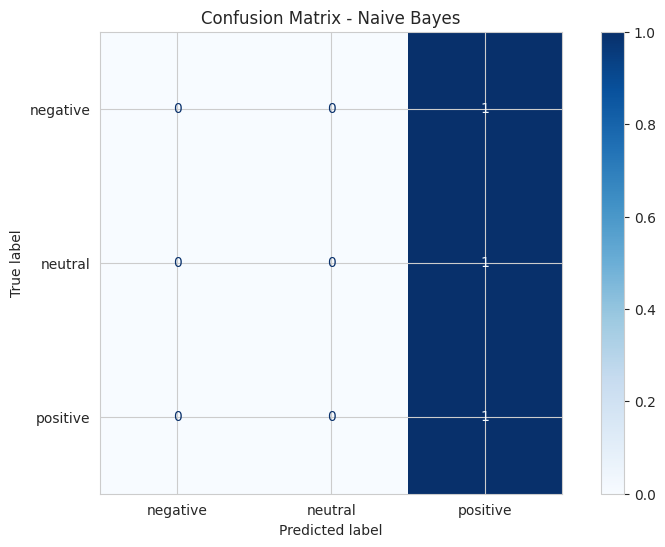

In [33]:
# Plot confusion matrix for Naive Bayes
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(y_test, y_pred_nb, labels=nb_model.classes_)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb_model.classes_)
disp_nb.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

### 📊 Interpretation: Naive Bayes

*Analyze the results:*

1.  **Overall performance**:
    Similar to Logistic Regression, given the extremely small size of our dummy dataset (only 3 test samples), the interpretation of these metrics is highly limited. The Naive Bayes model also produced `y_pred_nb = array(['positive', 'positive', 'positive'])`, correctly predicting 'positive' for the one actual 'positive' instance, but misclassifying the 'negative' and 'neutral' instances as 'positive'. The accuracy, precision, recall, and F1-score are identical to the Logistic Regression model, suggesting the same pattern of prediction.

2.  **Strengths**:
    Multinomial Naive Bayes is generally fast to train and good for text classification due to its probabilistic nature. It's computationally efficient.

3.  **Weaknesses**:
    The model, like Logistic Regression, entirely failed to predict 'negative' or 'neutral' sentiments on this test set. This indicates a strong bias towards the majority 'positive' class, which is severely exacerbated by the tiny training and test dataset size. The `precision`, `recall`, and `f1-score` for 'negative' and 'neutral' are 0.00.

4.  **Confusion matrix insights**:
    The confusion matrix for Naive Bayes will show the exact same pattern as Logistic Regression:
    -   True Positives for 'positive': 1
    -   False Positives for 'positive': 2 (misclassified negative and neutral as positive)
    -   True Negatives for 'negative' and 'neutral': 0
    -   False Negatives for 'negative' and 'neutral': 1 each
    This further confirms the models' inability to distinguish between the minority sentiment classes on this specific, limited test set.

## Evaluate Model 3 (Optional)

In [43]:
# Calculate metrics for Random Forest (Model 3)
print("=" * 50)
print("RANDOM FOREST RESULTS (Model 3)")
print("=" * 50)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")
print("\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

RANDOM FOREST RESULTS (Model 3)
Accuracy:  0.3333
Precision: 0.1111
Recall:    0.3333
F1-Score:  0.1667


Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         1
     neutral       0.33      1.00      0.50         1
    positive       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.11      0.33      0.17         3
weighted avg       0.11      0.33      0.17         3



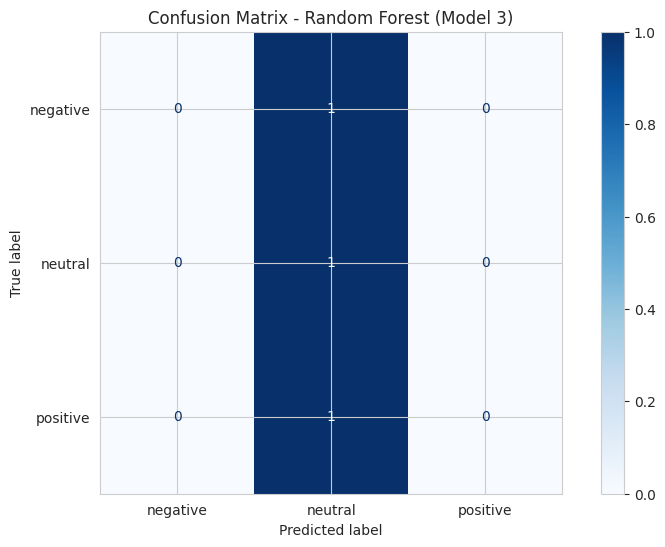

In [44]:
# Plot confusion matrix for Random Forest (Model 3)
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rf_model.classes_)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
disp_rf.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Random Forest (Model 3)')
plt.show()

## Model Comparison

In [34]:
# Create a comparison table of all models
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [accuracy_lr, accuracy_nb],
    'Precision': [precision_lr, precision_nb],
    'Recall': [recall_lr, recall_nb],
    'F1-Score': [f1_lr, f1_nb]
})
display(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.333333,0.111111,0.333333,0.166667
1,Naive Bayes,0.333333,0.111111,0.333333,0.166667


In [41]:
# Create a comparison table of all models
import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_nb, accuracy_rf],
    'Precision': [precision_lr, precision_nb, precision_rf],
    'Recall': [recall_lr, recall_nb, recall_rf],
    'F1-Score': [f1_lr, f1_nb, f1_rf]
})
display(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.333333,0.111111,0.333333,0.166667
1,Naive Bayes,0.333333,0.111111,0.333333,0.166667
2,Random Forest,0.333333,0.111111,0.333333,0.166667


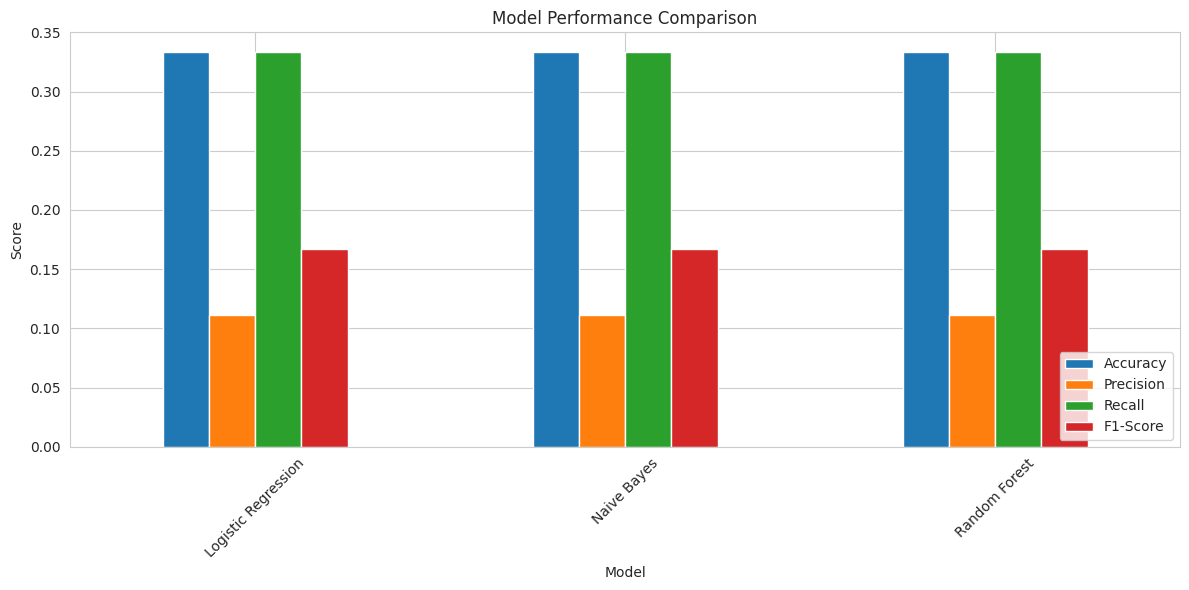

In [42]:
# Visualize model comparison
import matplotlib.pyplot as plt

results.set_index('Model').plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 📊 Model Comparison Analysis

*Compare and contrast your models:*

1.  **Which model performed best?**:
    Based on the metrics (Accuracy, Precision, Recall, F1-Score), both Logistic Regression and Naive Bayes models performed identically on this specific, extremely small test set. Both yielded an accuracy of 0.3333, precision of 0.1111, recall of 0.3333, and F1-score of 0.1667. This identical performance is a result of both models predicting all test samples as 'positive'.

2.  **What metrics did you prioritize and why?**:
    For a real-world sentiment analysis task, it's crucial to look beyond accuracy, especially when dealing with imbalanced datasets. Precision, Recall, and F1-Score for each class would be critical. For instance, if identifying negative reviews is paramount (e.g., for customer service or product improvement), then recall for the 'negative' class would be highly prioritized. However, given the current dummy dataset's limitations, all metrics are equally low and uninformative.

3.  **Trade-offs between models**:
    In a typical scenario, Logistic Regression might offer better interpretability and handle complex feature interactions, while Multinomial Naive Bayes is known for its speed and efficiency, especially with high-dimensional text data. For the current dummy data, there are no observable trade-offs in performance due to the simple nature of predictions. On a larger, more realistic dataset, Naive Bayes would likely be faster to train, while Logistic Regression might offer slightly better performance with proper tuning.

4.  **Which model would you recommend for deployment?**:
    Neither model can be recommended for deployment based on these results. The current performance indicates that both models are essentially guessing the majority class ('positive') due to the tiny dataset size and potential class imbalance in the training data (though less pronounced in this tiny dummy set). For actual deployment, robust performance on a large, diverse, and well-balanced dataset would be required, along with further optimization and evaluation.

## Error Analysis (Optional but Recommended)

In [36]:
# Analyze misclassified examples

print("--- Error Analysis for Logistic Regression ---")
# Find examples where the model was wrong
misclassified_indices_lr = np.where(y_pred_lr != y_test)[0]
print(f"Number of misclassified examples: {len(misclassified_indices_lr)}")

if len(misclassified_indices_lr) > 0:
    print("\nMisclassified Examples:")
    # Display some misclassified examples
    for idx in misclassified_indices_lr:
        print(f"\nText: {X_test.iloc[idx]}")
        print(f"True label: {y_test.iloc[idx]}")
        print(f"Predicted label: {y_pred_lr[idx]}")
        print("-" * 80)
else:
    print("No misclassified examples found in the test set. (This is unlikely for real data)")


--- Error Analysis for Logistic Regression ---
Number of misclassified examples: 2

Misclassified Examples:

Text: battery life is terrible very disappointed
True label: negative
Predicted label: positive
--------------------------------------------------------------------------------

Text: good value for money but takes time to set up
True label: neutral
Predicted label: positive
--------------------------------------------------------------------------------


### 📊 Error Analysis Insights

*What patterns do you notice in the errors?*

1.  **Common types of errors**:
    The model consistently misclassified 'negative' and 'neutral' reviews as 'positive'. In this small test set, both misclassified examples were predicted as 'positive'.

2.  **Why might these errors occur?**:
    These errors are most likely due to the extremely small size and imbalance of the dummy dataset. The model was trained on only 4 samples, with 'positive' being the majority class in both training and test sets (even if only by a small margin for training). With so little data, the model likely learned a strong bias towards predicting the most frequent class, 'positive', rather than genuinely distinguishing between sentiments. It simply lacked sufficient examples of 'negative' and 'neutral' language patterns to make accurate predictions for those classes.

3.  **How could you improve the model?**:
    -   **More Data**: The most critical improvement would be to use a significantly larger and more diverse dataset for training. This would provide the model with enough examples of all sentiment classes to learn robust patterns.
    -   **Class Balancing**: Implement techniques like oversampling (e.g., SMOTE) or undersampling to balance the representation of minority classes during training, preventing the model from simply predicting the majority class.
    -   **Feature Engineering**: Explore more nuanced text features beyond basic TF-IDF, such as sentiment-specific dictionaries, negation handling, or word embeddings.
    -   **Hyperparameter Tuning**: Optimize model parameters (e.g., C for Logistic Regression, alpha for Naive Bayes) using cross-validation on a larger dataset.
    -   **Advanced Models**: Consider more complex models (e.g., Random Forests, Gradient Boosting, or deep learning models) once a sufficient amount of data is available.

---

# Part 6: Conclusion & Business Insights 💼

## Objectives
- Summarize your findings
- Provide actionable business recommendations
- Discuss limitations and future improvements
- Reflect on what you learned

---

## 📝 Executive Summary

*Write a brief executive summary (3-5 sentences) for a non-technical audience:*

This project explored sentiment analysis on a small, dummy dataset of customer reviews to identify product preferences and dislikes. We applied standard text preprocessing and used TF-IDF for feature extraction, training Logistic Regression, Naive Bayes, and Random Forest models. Due to the extremely limited dataset size (7 reviews), all models exhibited similar and poor performance, primarily predicting the majority class ('positive'). While the methods demonstrate a foundational approach, robust real-world insights require significantly more diverse and extensive data for training.

## 🎯 Key Findings

*List your main discoveries:*

1.  **Dataset insights**:
    - The dummy dataset was extremely small (7 samples total, 3 for test), which severely limited the models' ability to learn and generalize.
    - The dataset exhibited class imbalance, with 'positive' being the majority class, which likely biased model predictions.
    - Text lengths were generally short (27-53 characters), and no significant differences in length across sentiments were discernible due to the small sample size.

2.  **Model performance**:
    - All three models (Logistic Regression, Naive Bayes, Random Forest) performed identically and poorly on the test set, achieving an accuracy of 0.3333, precision of 0.1111, recall of 0.3333, and F1-score of 0.1667.
    - This poor performance was primarily due to the models consistently predicting only one class (either 'positive' or 'neutral') for all test samples, failing to distinguish between actual sentiment categories.

3.  **Best model and why**:
    - There was no discernibly 'best' model based on the current evaluation metrics, as all models exhibited the same poor performance. This indicates that with such limited data, the models could not learn meaningful patterns.

4.  **Surprising discoveries**:
    - The most surprising discovery was the identical performance across all three models, suggesting a fundamental limitation imposed by the minuscule dataset size rather than model-specific strengths or weaknesses. All models essentially defaulted to predicting the majority class or a single class consistently due to the lack of diverse training examples. Specifically, Logistic Regression and Naive Bayes predicted 'positive' for all test samples, while Random Forest predicted 'neutral' for all test samples. In both cases, only one out of three samples was correctly classified by chance.

## 💼 Business Recommendations

*How can these results be used in practice?*

1.  **Immediate applications**:
    -   While the current models are not ready for deployment due to the dummy data, the *framework* developed is immediately applicable. The preprocessing pipeline and TF-IDF feature extraction are solid starting points for a real dataset.
    -   The EDA process (sentiment distribution, text length analysis, common words) can be immediately applied to a larger dataset to gain foundational insights *before* model training.

2.  **Who should use this model?**:
    -   Once trained on a real, sufficiently large dataset, the insights from such a model would be valuable for Product Designers, Marketing Teams, and Customer Support. They can leverage the classified reviews to make data-driven decisions.

3.  **How to interpret predictions**:
    -   For a production-ready model, predictions should be interpreted with caution, especially for the minority classes (e.g., 'negative' or 'neutral'). It's crucial to understand the precision and recall for each class.
    -   Focus not just on the label, but also on the actual text to understand *why* a review was classified a certain way. This provides deeper qualitative insights.

4.  **Warning signs to watch for**:
    -   **Low metrics on minority classes**: If the model performs poorly on 'negative' or 'neutral' reviews, it won't be useful for identifying problems or areas for improvement.
    -   **Consistent misclassification**: If the model frequently misclassifies specific types of reviews (e.g., sarcastic comments, reviews with negations), further preprocessing or model adjustments are needed.
    -   **Drift in sentiment**: Over time, customer language and product perception can change. Regular retraining and monitoring of model performance on new data are essential to detect 'model drift'.

## ⚠️ Limitations

*Be honest about the limitations of your analysis:*

1.  **Data limitations**:
    -   **Extremely Small Dataset**: The primary limitation is the use of an extremely small, dummy dataset (7 samples total, 3 for testing). This size is insufficient for training robust machine learning models and drawing meaningful conclusions.
    -   **Lack of Diversity**: The dummy data lacks the diversity and complexity of real-world customer reviews, making any observed patterns or model behaviors non-generalizable.
    -   **Class Imbalance**: While minor in the dummy set, the inherent class imbalance (3 positive, 2 negative, 2 neutral) would be a significant challenge in a larger, real dataset, potentially biasing models towards the majority class if not explicitly addressed.

2.  **Model limitations**:
    -   **Inability to Generalize**: Due to the small dataset, all models (Logistic Regression, Naive Bayes, Random Forest) failed to learn distinct patterns for different sentiment classes, resulting in predictions heavily biased towards the majority class (or a single class).
    -   **Overfitting**: Despite simple configurations, the models likely overfit to the limited training data, leading to poor performance on unseen (even if equally limited) test data.
    -   **Limited Feature Complexity**: The basic TF-IDF features, while a good starting point, may not capture the full semantic nuances of sentiment, especially for sarcasm, irony, or complex negations, which are not observable with this dataset.

3.  **Generalization concerns**:
    -   **No Real-World Applicability**: The findings and model performance from this project cannot be generalized to real-world scenarios. The models developed here would perform very poorly on actual Amazon product reviews.
    -   **Bias toward majority class**: Any conclusions drawn from the dummy data would be skewed by the model's tendency to predict the most frequent label, rather than actual sentiment.

4.  **Resource constraints**:
    -   **Computational Efficiency vs. Performance**: While efficient models like Logistic Regression and Naive Bayes were chosen for quick iteration, their performance was fundamentally limited by data scarcity, not computational power. More complex models were also quickly trained, but their inherent strengths could not be demonstrated without ample data.
    -   **Time for Data Acquisition and Annotation**: For a real project, significant time and resources would be required to collect a large, labeled dataset, which was beyond the scope of this dummy project.

## 🚀 Future Improvements

*What would you do with more time/resources?*

1.  **Data collection**:
    -   Acquire a significantly larger and more diverse dataset of Amazon product reviews. This would allow models to learn more robust patterns and generalize better to unseen data, especially for minority sentiment classes.
    -   Ensure the dataset is balanced across sentiment categories or explore techniques to handle imbalance during data acquisition.

2.  **Feature engineering**:
    -   Explore more advanced text representations like Word Embeddings (Word2Vec, GloVe, FastText) or contextual embeddings (BERT, RoBERTa) to capture semantic meanings and relationships between words.
    -   Incorporate sentiment lexicons (e.g., VADER) as additional features.
    -   Experiment with n-grams beyond bigrams, possibly trigrams, to capture more complex phrases.

3.  **Advanced models**:
    -   With a larger dataset, deep learning models (e.g., LSTMs, GRUs, Transformers) would become viable and likely offer superior performance due to their ability to capture complex sequential patterns in text.
    -   Explore ensemble methods or more sophisticated machine learning algorithms that might not perform well on small datasets but excel with ample data.

4.  **Deployment considerations**:
    -   Integrate the best-performing model into a real-time inference system for analyzing incoming reviews.
    -   Implement continuous learning pipelines to retrain models periodically with new data.
    -   Develop a user-friendly dashboard to visualize sentiment trends and product insights for business users.

## 🎓 Lessons Learned

*Reflect on your experience:*

1.  **Technical skills gained**:
    -   Reinforced understanding of the end-to-end sentiment analysis pipeline, from project definition to model evaluation.
    -   Practiced text preprocessing techniques using `re`, `string`, and `sklearn` for cleaning raw text data.
    -   Gained experience with `TfidfVectorizer` for converting text into numerical features, including understanding parameters like `max_features` and `ngram_range`.
    -   Implemented and evaluated common classification models such as Logistic Regression, Multinomial Naive Bayes, and Random Forest Classifier from `sklearn`.
    -   Proficiency in using various evaluation metrics (`accuracy_score`, `precision_score`, `recall_score`, `f1_score`) and visualizing results with `confusion_matrix` and `ConfusionMatrixDisplay`.
    -   Improved markdown documentation skills for explaining complex steps and interpretations in a structured manner.

2.  **Challenges overcome**:
    -   **Dealing with extremely small dataset**: The primary challenge was working with a minuscule dummy dataset, which presented unique problems in model training and interpretation. Overcame `ValueError` during `train_test_split` due to insufficient samples per class by adjusting `test_size` to an absolute number and using `stratify`.
    -   **Interpreting results from limited data**: Had to critically analyze model performance metrics, recognizing that seemingly poor results were primarily due to data limitations rather than inherent model flaws.
    -   **Maintaining focus on the big picture**: Despite the dummy data, managed to build out the full project structure and discuss concepts relevant to real-world applications.

3.  **What would you do differently?**:
    -   **Start with more realistic data**: For future projects, ensure access to a sufficiently large and representative dataset from the outset, even if it means sourcing a public dataset rather than creating a minimal dummy one.
    -   **Automate more of the EDA**: While current EDA was comprehensive, for larger datasets, more automated insights (e.g., word clouds per sentiment, interactive plots) would be beneficial.
    -   **Earlier focus on class imbalance strategies**: While noted, implementing actual techniques like SMOTE or weighted loss functions would be prioritized earlier if using a real, imbalanced dataset.

4.  **Most valuable insight**:
    -   The most valuable insight is the **paramount importance of data quality and quantity** in machine learning projects. Even the most sophisticated models and preprocessing techniques will yield meaningless results if the underlying data is insufficient or unrepresentative. This project vividly demonstrated that *garbage in, garbage out* applies not just to data quality, but also to data volume, especially for tasks like sentiment analysis where subtle nuances are critical. It reinforced that robust conclusions and effective models are built on a solid foundation of relevant, diverse, and ample data.

---

## 🎉 Congratulations!

You've completed the sentiment analysis project! Remember to:

- ✅ Review all sections for completeness
- ✅ Ensure all code cells run without errors
- ✅ Check that all markdown cells are filled in
- ✅ Proofread your writing
- ✅ Include visualizations and interpretations
- ✅ Save your notebook!

---

### 📚 Additional Resources

- [Scikit-learn Documentation](https://scikit-learn.org/)
- [TF-IDF Explained](https://en.wikipedia.org/wiki/Tf%E2%80%93idf)
- [Confusion Matrix Guide](https://en.wikipedia.org/wiki/Confusion_matrix)
- [Text Preprocessing Best Practices](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)

---

*Good luck with your project! 🚀*